In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from scipy import stats


In [7]:
df = pd.read_csv('BMW sales data (2010-2024).csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [11]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [14]:
df.shape




(50000, 11)

In [16]:
df.isnull().sum()

,0
Model,0
Year,0
Region,0
Color,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_KM,0
Price_USD,0
Sales_Volume,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.head(10)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
5,5 Series,2017,Middle East,Silver,Diesel,Manual,1.9,171362,42926,1232,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low
8,X3,2016,South America,White,Diesel,Automatic,1.7,48073,116482,8944,High
9,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,Low


In [24]:
df.columns.tolist()

['Model',
 'Year',
 'Region',
 'Color',
 'Fuel_Type',
 'Transmission',
 'Engine_Size_L',
 'Mileage_KM',
 'Price_USD',
 'Sales_Volume',
 'Sales_Classification']

In [26]:
df.dtypes

,0
Model,object
Year,int64
Region,object
Color,object
Fuel_Type,object
Transmission,object
Engine_Size_L,float64
Mileage_KM,int64
Price_USD,int64
Sales_Volume,int64


In [28]:
df.columns.tolist()

['Model',
 'Year',
 'Region',
 'Color',
 'Fuel_Type',
 'Transmission',
 'Engine_Size_L',
 'Mileage_KM',
 'Price_USD',
 'Sales_Volume',
 'Sales_Classification']

In [37]:
df['Model'].value_counts()

,count
Model,
7 Series,4666
i3,4618
i8,4606
3 Series,4595
5 Series,4592
X1,4570
X3,4497
X5,4487
M5,4478


In [39]:
df['Model'].nunique()

11

In [43]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Hybrid,12716
Petrol,12550
Electric,12471
Diesel,12263


In [45]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,25154
Automatic,24846


In [48]:
df['Price_USD'].min()

30000

In [50]:
df['Price_USD'].max()

119998

In [51]:
# feature engineering


In [54]:
df['Sales_Volume']


,Sales_Volume
0,8300
1,3428
2,6994
3,4047
4,3080
...,...
49995,8182
49996,9816
49997,8280
49998,9486


In [58]:
df['Price_inr'] = df['Price_USD']*92
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072


In [61]:
df['revenue']  = df['Sales_Volume']*df['Price_USD']
df


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076


In [64]:
df['Revenue_INR'] = df['revenue'] * 86
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536


In [66]:
df['Engine_Size_L']

,Engine_Size_L
0,3.5
1,1.6
2,4.5
3,1.7
4,2.1
...,...
49995,4.6
49996,4.2
49997,4.5
49998,3.8


In [68]:
df['Engine_category '] = pd.cut(
    df['Engine_Size_L'],
    bins = [0,4,6,8],
    labels = ['small','medium','large']
)
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small


In [70]:
df['Price_categgory'] = pd.cut(
    df['Price_USD'],
    bins = 3 ,
    labels = ['low','medium','high']
)
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category,Price_categgory
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small,high
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small,medium
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium,high
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small,medium
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium,low
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium,low
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium,low
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small,low


In [72]:
df['Price_categgory'] = pd.cut(
    df['Price_inr'],
    bins = 3 ,
    labels = ['low','medium','high']
)
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category,Price_categgory
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small,high
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small,medium
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium,high
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small,medium
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium,low
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium,low
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium,low
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small,low


In [75]:
df['Milage_KM'] = pd.cut(
    df['Mileage_KM'],
    bins = 3 ,
    labels = ['low','medium','high']
)
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category,Price_categgory,Milage_KM
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small,high,high
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small,medium,medium
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium,high,low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small,medium,low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small,low,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium,low,high
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium,low,high
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium,low,high
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small,low,low


In [77]:
df['Demand'] = pd.cut(
    df['Sales_Volume'],
    bins = 3 ,
    labels = ['low','medium','high']
)
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category,Price_categgory,Milage_KM,Demand
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small,high,high,high
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small,medium,medium,medium
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium,high,low,high
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small,medium,low,medium
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small,low,medium,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium,low,high,high
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium,low,high,high
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium,low,high,high
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small,low,low,high


In [79]:
# kpi analysis


In [84]:
df.groupby('Model')['Sales_Volume'].sum()

,Sales_Volume
Model,
3 Series,23281303
5 Series,23097519
7 Series,23786466
M3,22349694
M5,22779688
X1,23406060
X3,22745529
X5,22709749
X6,22661986


In [88]:

# Average Car Price
df['Price_USD'].mean()

np.float64(75034.6009)

In [89]:
# Total Models
df['Model'].nunique()

11

In [91]:

# Average Car Price
df['Price_inr'].mean()

np.float64(6903183.2828)

In [93]:
df['Price_inr'].mode()

,Price_inr
0,2847216


In [95]:
df['Price_inr'].max()

11039816

In [97]:
df['Price_inr'].min()

2760000

In [100]:
df['Engine_Size_L'].mean()


np.float64(3.24718)

In [104]:
df['Mileage_KM'].mean()

np.float64(100307.20314)

In [114]:
df.groupby('Model')['Sales_Volume'].sum().sort_values(ascending=False)

,Sales_Volume
Model,
7 Series,23786466
i8,23423891
X1,23406060
3 Series,23281303
i3,23133849
5 Series,23097519
M5,22779688
X3,22745529
X5,22709749


In [117]:
df.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=False).head(1)

,Sales_Volume
Region,
Asia,42974277


In [123]:
df.groupby('Model')['revenue'] .sum().sort_values(ascending=False).head(1)

,revenue
Model,
7 Series,1790070249282


In [126]:
df.groupby('Fuel_Type')['revenue'] .sum().sort_values(ascending=False).head(1)

,revenue
Fuel_Type,
Hybrid,4820671669300


In [128]:
df.groupby('Year')['revenue'] .sum().sort_values(ascending=False).head(1)

,revenue
Year,
2022,1344427738820


In [131]:
df.groupby('Region')['revenue'].sum().sort_values(ascending=False)

,revenue
Region,
Asia,3250635961348
Europe,3188079573212
North America,3182938635076
Middle East,3167783530851
South America,3113805414620
Africa,3108999419352


In [133]:
# distubtion anaylsis


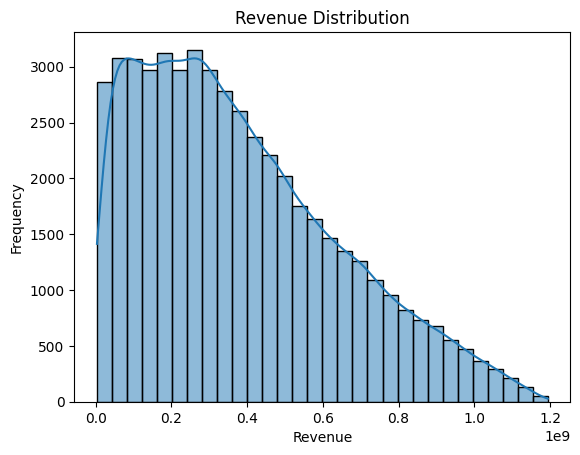

np.float64(0.6888472794072193)

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['revenue'], bins=30, kde=True)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()
df['revenue'].skew()

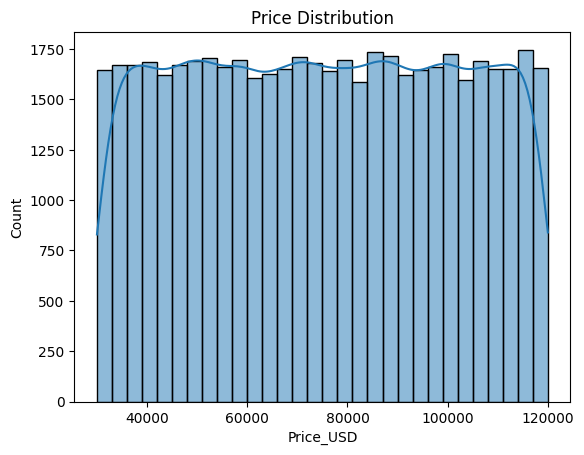

In [141]:


sns.histplot(df['Price_USD'], bins=30, kde=True)

plt.title('Price Distribution')
plt.show()

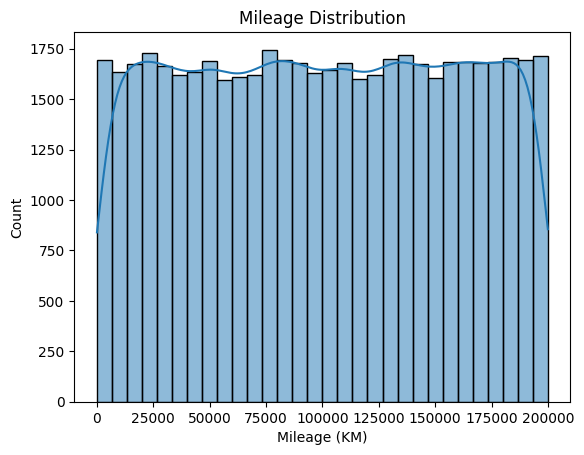

In [143]:

sns.histplot(df['Mileage_KM'], bins=30, kde=True)

plt.title('Mileage Distribution')
plt.xlabel('Mileage (KM)')
plt.ylabel('Count')

plt.show()

<Axes: xlabel='Model', ylabel='Price_USD'>

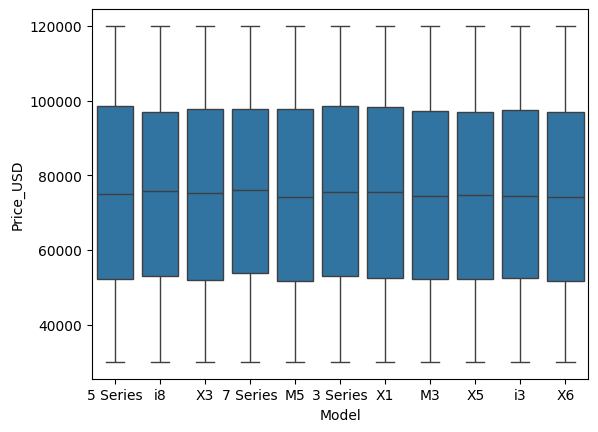

In [148]:
sns.boxplot(
    data=df,
    x='Model',
    y='Price_USD'
)

In [149]:
# Business Analysis & Visualization

<Axes: xlabel='Model', ylabel='count'>

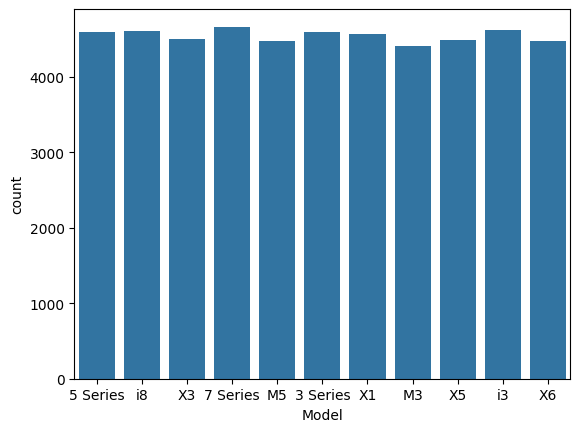

In [156]:
sns.countplot(
    x = df['Model'],

)


In [172]:
most_sell_df = ( df.groupby('Model')['Sales_Volume'].sum().sort_values(ascending=False).head(10))
most_sell_df

,Sales_Volume
Model,
7 Series,23786466
i8,23423891
X1,23406060
3 Series,23281303
i3,23133849
5 Series,23097519
M5,22779688
X3,22745529
X5,22709749


In [174]:
import plotly.express as px

top10_models = (
    df.groupby('Model')['Sales_Volume']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)


fig = px.bar(
    top10_models,
    x='Model',
    y='Sales_Volume',
    title='Top 10 Best Selling Models',
    text_auto=True
)

fig.show()

In [178]:
top10_revenue = ( df.groupby('Model')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top10_revenue

,Model,revenue
0,7 Series,1790070249282
1,3 Series,1768534028214
2,i8,1764743448529
3,X1,1752985285361
4,5 Series,1735712423092
5,i3,1724197530210
6,X5,1708653383772
7,X3,1707951188482
8,M5,1698467355916
9,X6,1693423254979


In [193]:
fig = px.bar(
      top10_revenue,
     x = 'Model',
     y = 'revenue',

    title='Top 10 Best Selling Models',
    text_auto=True

)

fig.show()




In [194]:
highest_sales_region = ( df.groupby('Region')['Sales_Volume']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
fig  = px.bar(
    highest_sales_region,

    x = 'Region',
    y = 'Sales_Volume',
    title = 'Highest Sales Region' ,
    text_auto = True
)
fig.show()






In [196]:
revenue_per_region = ( df.groupby('Region')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

)
fig  = px.bar(
    revenue_per_region,

    x = 'Region',
    y = 'revenue',
    title = 'Revenue Per Region' ,
    text_auto = True

)
fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['revenue'] but received: Region

In [199]:
revenue_per_region = ( df.groupby('Region')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)


fig  = px.bar(
    revenue_per_region,

    x = 'Region',
    y = 'revenue',
    title = 'Revenue Per Region' ,
    text_auto = True

)
fig.show()

In [214]:
fuel_type_domination  = df.groupby('Fuel_Type')['Sales_Volume'].sum().sort_values(ascending=False).reset_index()
fuel_type_domination

fig = px.pie(
    fuel_type_domination,
    names = 'Fuel_Type',
    values = 'Sales_Volume',
    title = 'Fuel Type Domination',
   color_discrete_sequence=['orange']

)
fig.show()




In [220]:
fuel_type_revenue = df.groupby('Fuel_Type')['revenue'].sum().sort_values(ascending=False).reset_index()


fig = px.bar(
    fuel_type_revenue,
    x = 'Fuel_Type',
    y = 'revenue',
    title = 'Fuel Type Revenue',
    text_auto = True
)

fig.show()

In [223]:
# Automatic vs Manual

df


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Price_inr,revenue,Revenue_INR,Engine_category,Price_categgory,Milage_KM,Demand
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,9084080,819542000,70480612000,small,high,high,high
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,7288148,271562732,23354394952,small,medium,medium,medium
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,10420380,792175410,68127085260,medium,high,low,high
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,5609332,246749637,21220468782,small,medium,low,medium
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,4590616,153685840,13216982240,small,low,medium,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,3949744,351269624,30209187664,medium,low,high,high
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,4481688,478176624,41123189664,medium,low,high,high
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,4243592,381923280,32845402080,medium,low,high,high
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,5388072,555557076,47777908536,small,low,low,high


In [227]:
transmissiom = df.groupby('Transmission')['Sales_Volume'].sum().sort_values(ascending=False).reset_index()


fig = px.bar(
    transmissiom,
    x = 'Transmission',
    y = 'Sales_Volume',
    title = 'Transmission',
    text_auto = True
)

fig.show()

In [229]:
year_analysis = (
    df.groupby('Year')['revenue']
      .sum()
      .sort_values()
      .reset_index()
)

fig = px.line(
    year_analysis,
    x='Year',
    y='revenue',
    title='Revenue Trend By Year',
    markers=True
)

fig.show()

In [231]:
top_models = (
    df.groupby('Model')['Sales_Volume']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_models,
    x='Model',
    y='Sales_Volume',
    title='Top 10 Best Selling Models',
    text_auto=True
)

fig.show()

In [233]:
transmission = (
    df.groupby('Transmission')['Sales_Volume']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    transmission,
    x='Transmission',
    y='Sales_Volume',
    title='Transmission Analysis',
    text_auto=True
)

fig.show()

In [240]:
# statitics

df['revenue'].mean()



np.float64(380244850.68918)

In [237]:
df['revenue'].std()

262340599.4233638

In [241]:
df['revenue'].var()

6.882259010580982e+16

In [247]:
cv = ( df['revenue'].std() /  df['revenue'].mean())*100
cv

np.float64(68.9925449214844)

In [249]:
df['Price_USD'].mean()

np.float64(75034.6009)

In [251]:
cv = (
    df['Price_USD'].std()
    /
    df['Price_USD'].mean()
) * 100

cv

np.float64(34.6483469891057)

<Axes: >

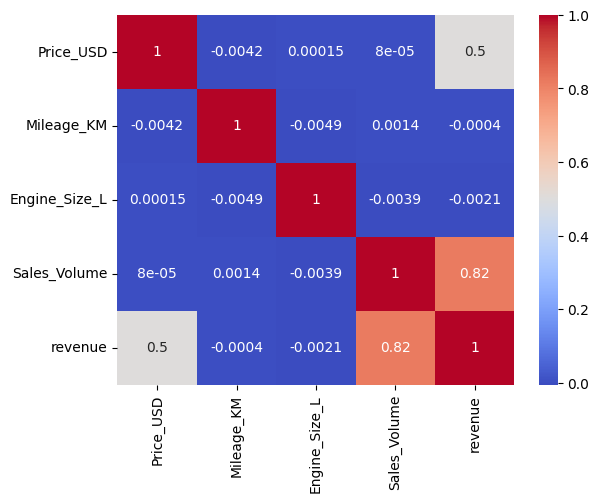

In [257]:
corr_matrix = df[
     [
        'Price_USD',
        'Mileage_KM',
        'Engine_Size_L',
        'Sales_Volume',
        'revenue'
    ]
].corr()

corr_matrix

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

In [259]:
pd.crosstab(
    df['Fuel_Type'],
    df['Transmission']
)

Transmission,Automatic,Manual
Fuel_Type,,
Diesel,6067,6196
Electric,6255,6216
Hybrid,6318,6398
Petrol,6206,6344


In [264]:
pd.crosstab(
    df['Region'],
    df['Model']
)

Model,3 Series,5 Series,7 Series,M3,M5,X1,X3,X5,X6,i3,i8
Region,,,,,,,,,,,
Africa,757,789,738,694,742,768,731,779,741,783,731
Asia,767,787,784,779,770,816,741,746,753,734,777
Europe,764,754,763,729,763,753,742,712,731,800,823
Middle East,772,743,810,729,771,747,759,780,754,778,730
North America,760,741,791,762,732,742,790,751,737,780,749
South America,775,778,780,720,700,744,734,719,762,743,796


In [266]:
pd.crosstab(
    df['Transmission'],
    df['Fuel_Type']
)

Fuel_Type,Diesel,Electric,Hybrid,Petrol
Transmission,,,,
Automatic,6067,6255,6318,6206
Manual,6196,6216,6398,6344


In [270]:
pd.pivot_table(
    df,
    index='Model',
    columns = 'Year',
    values='revenue',
    aggfunc='sum'
)


Year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Model,,,,,,,,,,,,,,,
3 Series,123206927162,112158137942,104983651057,110027948071,126664028300,123642903728,129698953207,112375019878,121807552107,111734464764,121590272086,122249226604,119685223915,113188690600,115521028793
5 Series,106920016980,117534126070,114151647311,112719333498,109970720994,117899813503,131081665600,122950598705,104857381532,117437633230,117782581625,100485683494,121926198899,110765164408,129229857243
7 Series,104964553578,121581782347,114338958403,116717197102,125187606893,125946080416,112116016568,132758608891,116224978994,111402690201,114750171970,120203591145,127227613709,118170171597,128480227468
M3,115595705451,104034344336,102379450730,111673398942,121150366184,110232838978,111473817026,104300887244,110604887197,104821462152,110498098508,120274879666,126465321771,118311487905,95687440532
M5,118604385862,117496361893,98693999007,117671842978,98032672312,102497649093,100438472794,113180615450,123441465930,124876494237,113745750907,126006888412,120311324206,107830451478,115638981357
X1,111257521106,125185650431,127285905581,124753447920,127543477611,113254123341,117128521843,106760959508,100728874893,124370223275,118544549161,116272945171,115072586869,111692988008,113133510643
X3,119715562875,114893439771,126050677489,114022994220,103824431511,104937242772,124812140993,110469082244,106421266892,110871083508,103443669404,110895446450,120296110930,111915128081,125382911342
X5,115051447400,106073662421,113211013861,110357360351,122577692294,111818069374,116532555007,114236965405,118475531794,124125183688,109389410569,110285709860,132767425394,95925308820,107826047534
X6,103974104061,106168792972,101889439348,111017775714,118787133674,102506074668,101388921741,106399546522,113090673779,119187763456,106338618395,116224406862,129556338996,114477380916,142416283875


In [275]:
pd.pivot_table(
    df,
    index='Model',
    columns = 'Region',
    values='Sales_Volume',
    aggfunc='sum'
)


Region,Africa,Asia,Europe,Middle East,North America,South America
Model,,,,,,
3 Series,3892595,3962239,3959930,3889367,3879277,3697895
5 Series,4020702,3935629,3855515,3708878,3691777,3885018
7 Series,3699471,4004066,3914409,4080751,4087259,4000510
M3,3448709,3935579,3649697,3832415,3792785,3690509
M5,3676252,3928390,4002667,3936889,3602546,3632944
X1,3928136,4192289,3850033,3818212,3987029,3630361
X3,3742723,3796115,3705572,3745004,4056192,3699923
X5,3972541,3748736,3688138,3946209,3744219,3609906
X6,3630167,3756074,3772519,3777388,3702034,4023804


In [276]:
model_share = (
    df.groupby('Model')['revenue'].sum().sort_values(ascending=False)
)

market_share = (
    model_share/
    model_share.sum()
    * 100
)

market_share.head(10)

,revenue
Model,
7 Series,9.415356
3 Series,9.302080
i8,9.282143
X1,9.220297
5 Series,9.129446
i3,9.068880
X5,8.987122
X3,8.983428
M5,8.933546
